### Importação dos dados



In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [4]:
loja['Loja'] = 'Loja 1'
loja2['Loja'] = 'Loja 2'
loja3['Loja'] = 'Loja 3'
loja4['Loja'] = 'Loja 4'

df_completo = pd.concat([loja, loja2, loja3, loja4], ignore_index = True)

print('Visualizando dados Combinados ')
df_completo.head()

Visualizando dados Combinados 


,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon,Loja
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja 1
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja 1
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja 1
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja 1


In [ ]:
faturamento_por_loja = df_completo.groupby('Loja')['Preço'].sum()

print("--- Fatura total por loja ---")

print(faturamento_por_loja.map("R${:,.2f}".format).str.replace(',','#').str.replace('.',',').str.replace('#','.'))

--- Fatura total por loja ---
Loja
Loja 1    R$1.534.509,12
Loja 2    R$1.488.459,06
Loja 3    R$1.464.025,03
Loja 4    R$1.384.497,58
Name: Preço, dtype: object


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


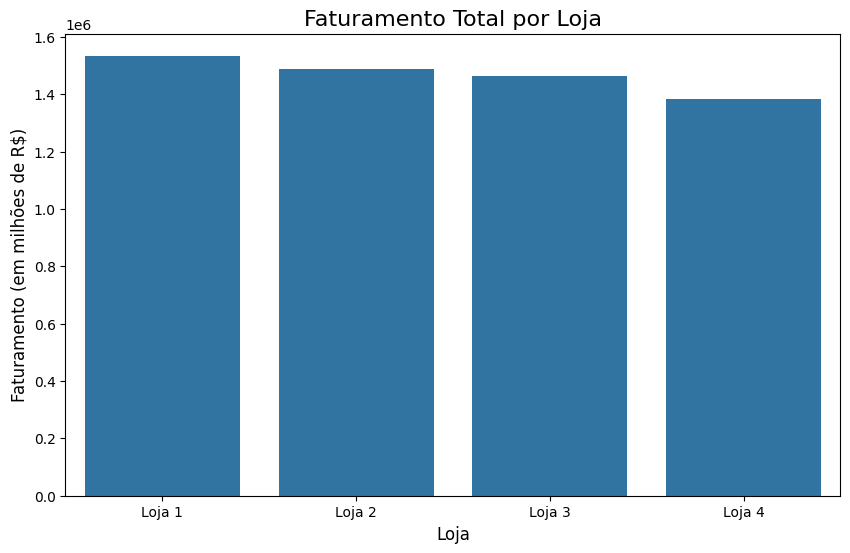

In [ ]:
faturamento_por_loja = df_completo.groupby('Loja')['Preço'].sum()

plt.figure(figsize=(10,6))

sns.barplot(x=faturamento_por_loja.index, y=faturamento_por_loja.values)

plt.title('Faturamento Total por Loja', fontsize=16)
plt.xlabel('Loja',fontsize=12)
plt.ylabel('Faturamento (em milhões de R$)', fontsize=12)

plt.show()

# 2. Vendas por Categoria

In [ ]:
vendas_por_categoria = df_completo.groupby(['Loja','Categoria do Produto']).size()

print('--- Quantidade de Vendas por Categoria em cada Loja ---')

print(vendas_por_categoria)


--- Quantidade de Vendas por Categoria em cada Loja ---
Loja    Categoria do Produto 
Loja 1  brinquedos               324
        eletrodomesticos         312
        eletronicos              448
        esporte e lazer          284
        instrumentos musicais    182
        livros                   173
        moveis                   465
        utilidades domesticas    171
Loja 2  brinquedos               313
        eletrodomesticos         305
        eletronicos              422
        esporte e lazer          275
        instrumentos musicais    224
        livros                   197
        moveis                   442
        utilidades domesticas    181
Loja 3  brinquedos               315
        eletrodomesticos         278
        eletronicos              451
        esporte e lazer          277
        instrumentos musicais    177
        livros                   185
        moveis                   499
        utilidades domesticas    177
Loja 4  brinquedos        

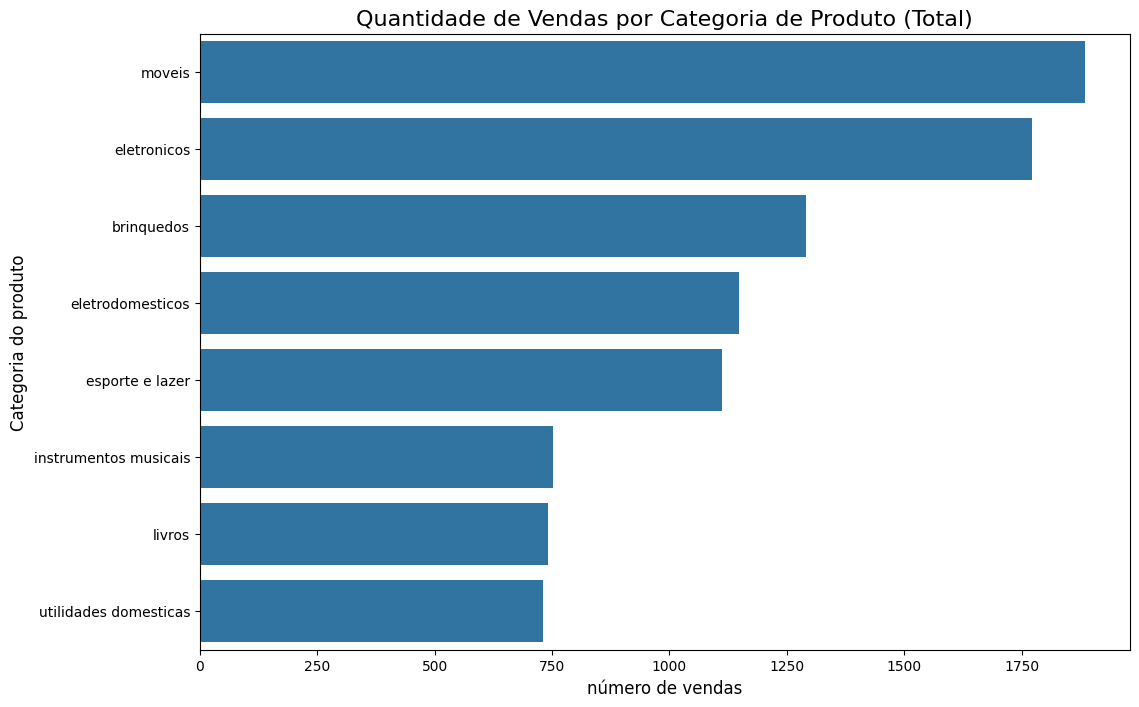

In [9]:
vendas_por_categoria_total= df_completo['Categoria do Produto'].value_counts()


plt.figure(figsize=(12,8))
sns.barplot(x=vendas_por_categoria_total.values,y=vendas_por_categoria_total.index, orient ='h')

plt.title('Quantidade de Vendas por Categoria de Produto (Total)',fontsize=16)
plt.xlabel('número de vendas',fontsize=12)
plt.ylabel('Categoria do produto',fontsize=12)

plt.show()


# 3. Média de Avaliação das Lojas


In [ ]:
avaliacao_media_por_loja = df_completo.groupby('Loja')['Avaliação da compra'].mean()

print('--- Média de Avaliação por Loja ---')

print(avaliacao_media_por_loja)

--- Média de Avaliação por Loja ---
Loja
Loja 1    3.976685
Loja 2    4.037304
Loja 3    4.048326
Loja 4    3.995759
Name: Avaliação da compra, dtype: float64


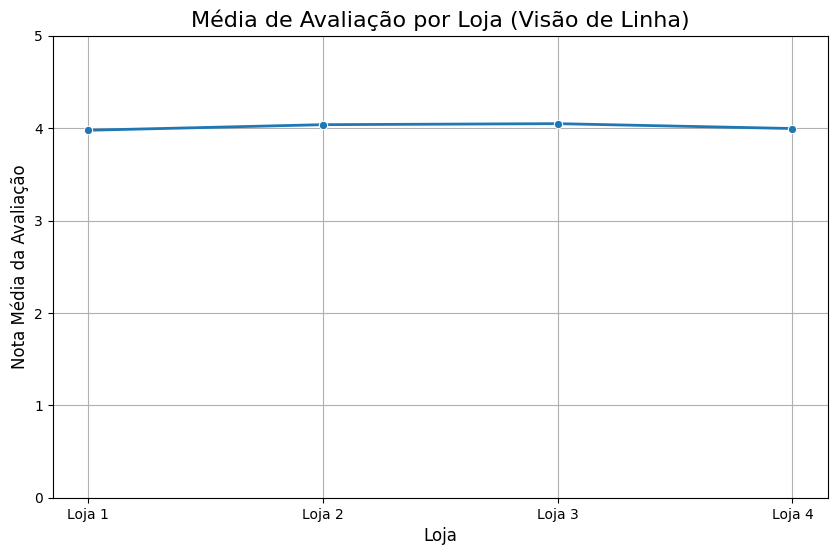

In [7]:

avaliacao_media_por_loja = df_completo.groupby('Loja')['Avaliação da compra'].mean()

plt.figure(figsize=(10, 6))


sns.lineplot(x=avaliacao_media_por_loja.index, y=avaliacao_media_por_loja.values, marker="o", lw=2)

plt.title('Média de Avaliação por Loja (Visão de Linha)', fontsize=16)
plt.xlabel('Loja', fontsize=12)
plt.ylabel('Nota Média da Avaliação', fontsize=12)

plt.ylim(0, 5)

plt.grid(True)

plt.show()

# 4. Produtos Mais e Menos Vendidos

In [ ]:
vendas_por_categoria_loja = df_completo.groupby('Loja')['Produto'].value_counts()

mais_vendidos=vendas_por_categoria_loja.groupby('Loja').head(5)

menos_vendidos=vendas_por_categoria_loja.groupby('Loja').tail(5)

print('--- Os 5 produtos mais vendidos por Loja ---')
print(mais_vendidos)

print('\n'+'='*40+'\n')

print('--- Os 5 produtos menos vendidos por Loja ---')
print(menos_vendidos)

--- Os 5 produtos mais vendidos por Loja ---
Loja    Produto                 
Loja 1  Guarda roupas               60
        Micro-ondas                 60
        TV Led UHD 4K               60
        Secadora de roupas          58
        Blocos de montar            56
Loja 2  Iniciando em programação    65
        Micro-ondas                 62
        Bateria                     61
        Pandeiro                    58
        Violão                      58
Loja 3  Kit banquetas               57
        Cama king                   56
        Mesa de jantar              56
        Cômoda                      55
        Jogo de panelas             55
Loja 4  Cama box                    62
        Faqueiro                    59
        Cama king                   56
        Dashboards com Power BI     56
        Carrinho controle remoto    55
Name: count, dtype: int64


--- Os 5 produtos menos vendidos por Loja ---
Loja    Produto           
Loja 1  Mochila               39
        

# 5. Frete Médio por Loja

In [ ]:
frete_medio_por_loja = df_completo.groupby('Loja')['Frete'].mean()


print('--- Custo Médio do Frete por Loja ---')

print(frete_medio_por_loja.map('R$ {:.2f}'.format))

--- Custo Médio do Frete por Loja ---
Loja
Loja 1    R$ 34.69
Loja 2    R$ 33.62
Loja 3    R$ 33.07
Loja 4    R$ 31.28
Name: Frete, dtype: object


## Relatório Final: Recomendação de Venda de Loja para o Senhor João

### 1. Introdução

Este relatório tem como objetivo analisar o desempenho das quatro lojas de e-commerce do Senhor João, considerando métricas chave como faturamento total, vendas por categoria de produto, avaliação média dos clientes, produtos mais e menos vendidos, e custo médio do frete. Com base nesta análise detalhada, será fornecida uma recomendação fundamentada sobre qual loja deveria ser considerada para venda, identificando seus pontos fortes e fracos.

### 2. Análise dos Dados

#### 2.1. Faturamento Total por Loja

A análise do faturamento total por loja revelou as seguintes cifras:

*   **Loja 1**: R$1.534.509,12
*   **Loja 2**: R$1.488.459,06
*   **Loja 3**: R$1.464.025,03
*   **Loja 4**: R$1.384.497,58

Conforme visualizado no gráfico de barras de 'Faturamento Total por Loja', a Loja 1 apresenta o maior faturamento, enquanto a Loja 4 possui o menor. Há uma diferença notável entre a loja de maior e a de menor faturamento, indicando variações significativas na performance de vendas.

#### 2.2. Vendas por Categoria de Produto

A quantidade de vendas por categoria de produto em cada loja e o total geral são apresentados a seguir:

**Total Geral de Vendas por Categoria:**

*   moveis: 1886 vendas
*   eletronicos: 1772 vendas
*   brinquedos: 1290 vendas
*   eletrodomesticos: 1149 vendas
*   esporte e lazer: 1113 vendas
*   instrumentos musicais: 754 vendas
*   livros: 772 vendas
*   utilidades domesticas: 730 vendas

No geral, 'moveis' e 'eletronicos' são as categorias mais vendidas, enquanto 'utilidades domesticas', 'instrumentos musicais' e 'livros' são as menos vendidas. A Loja 1, por exemplo, tem 'moveis' como categoria líder com 465 vendas, enquanto a Loja 4 também se destaca em 'moveis' com 480 vendas. É importante observar as categorias de destaque e as de menor desempenho em cada loja para entender as especialidades e os desafios.

#### 2.3. Média de Avaliação de Clientes por Loja

A média de avaliação da compra por loja é um indicador crucial da satisfação do cliente:

*   **Loja 1**: 3.98
*   **Loja 2**: 4.04
*   **Loja 3**: 4.05
*   **Loja 4**: 4.00

O gráfico de linha 'Média de Avaliação por Loja' mostra que todas as lojas mantêm uma média de avaliação acima de 3.9, com a Loja 3 e a Loja 2 apresentando as maiores médias, indicando um bom nível de satisfação do cliente em geral. A Loja 1 tem a menor média, embora ainda seja satisfatória.

#### 2.4. Produtos Mais e Menos Vendidos por Loja

Analisar os produtos mais e menos vendidos oferece insights sobre o portfólio de cada loja:

**Os 5 produtos mais vendidos por Loja:**

*   **Loja 1**: Guarda roupas (60), Micro-ondas (60), TV Led UHD 4K (60), Secadora de roupas (58), Blocos de montar (56)
*   **Loja 2**: Iniciando em programação (65), Micro-ondas (62), Bateria (61), Pandeiro (58), Violão (58)
*   **Loja 3**: Kit banquetas (57), Cama king (56), Mesa de jantar (56), Cômoda (55), Jogo de panelas (55)
*   **Loja 4**: Cama box (62), Faqueiro (59), Cama king (56), Dashboards com Power BI (56), Carrinho controle remoto (55)

**Os 5 produtos menos vendidos por Loja:**

*   **Loja 1**: Mochila (39), Pandeiro (36), Panela de pressão (35), Celular ABXY (33), Headset (33)
*   **Loja 2**: Fone de ouvido (37), Poltrona (35), Impressora (34), Mesa de jantar (34), Jogo de tabuleiro (32)
*   **Loja 3**: Guitarra (38), Jogo de copos (36), Micro-ondas (36), Mochila (36), Blocos de montar (35)
*   **Loja 4**: Geladeira (38), Lavadora de roupas (38), Violão (37), Guarda roupas (34), Guitarra (33)

É notável a diversidade dos produtos mais vendidos, o que demonstra que cada loja pode ter um nicho de mercado diferente. Por exemplo, a Loja 2 tem um destaque em 'Iniciando em programação', indicando um possível foco em livros ou cursos, enquanto as outras lojas vendem mais itens físicos como móveis e eletrodomésticos. Os produtos menos vendidos também são variados, mas as baixas quantidades indicam que esses itens podem estar saturados ou com baixa demanda em suas respectivas lojas.

#### 2.5. Frete Médio por Loja

O custo médio do frete por loja é um fator importante para a rentabilidade e competitividade:

*   **Loja 1**: R$ 34.69
*   **Loja 2**: R$ 33.62
*   **Loja 3**: R$ 33.07
*   **Loja 4**: R$ 31.28

A Loja 4 apresenta o frete médio mais baixo, o que pode ser uma vantagem competitiva em termos de custos para o cliente. A Loja 1 tem o frete médio mais alto.

### 3. Conclusão e Recomendação

Com base na análise abrangente dos dados, a recomendação para o Senhor João é vender a **Loja 4**.

**Justificativa:**

A **Loja 4** apresenta o menor faturamento total (R$1.384.497,58) entre as quatro lojas, indicando que é a menos lucrativa. Embora sua média de avaliação de clientes (4.00) seja boa e seu frete médio seja o mais baixo (R$ 31.28), esses pontos positivos não compensam o desempenho financeiro inferior em comparação com as outras lojas.

*   **Faturamento**: Claramente a Loja 4 está atrás das outras em termos de receita bruta.
*   **Avaliação do Cliente**: Embora tenha uma boa avaliação, não é a melhor, e a diferença em relação às outras lojas é marginal.
*   **Frete Médio**: O frete médio mais baixo é um ponto positivo, mas não é suficiente para impulsionar o faturamento ao nível das demais.
*   **Produtos Vendidos**: A lista de produtos mais e menos vendidos mostra uma performance similar às outras lojas, sem um destaque que justifique sua manutenção apesar do baixo faturamento.

Manter a Loja 4 pode significar um esforço desproporcional para um retorno menor. Vender a Loja 4 permitiria ao Senhor João concentrar recursos e esforços nas lojas de melhor desempenho (especialmente a Loja 1, que lidera em faturamento, ou as Lojas 2 e 3, que têm melhores avaliações de cliente e faturamentos mais próximos), otimizando assim seu portfólio de negócios e buscando maior rentabilidade geral.

## Abordagem 1: O Mapa de Pontos (Gráfico de Dispersão)

<function matplotlib.pyplot.show(close=None, block=None)>

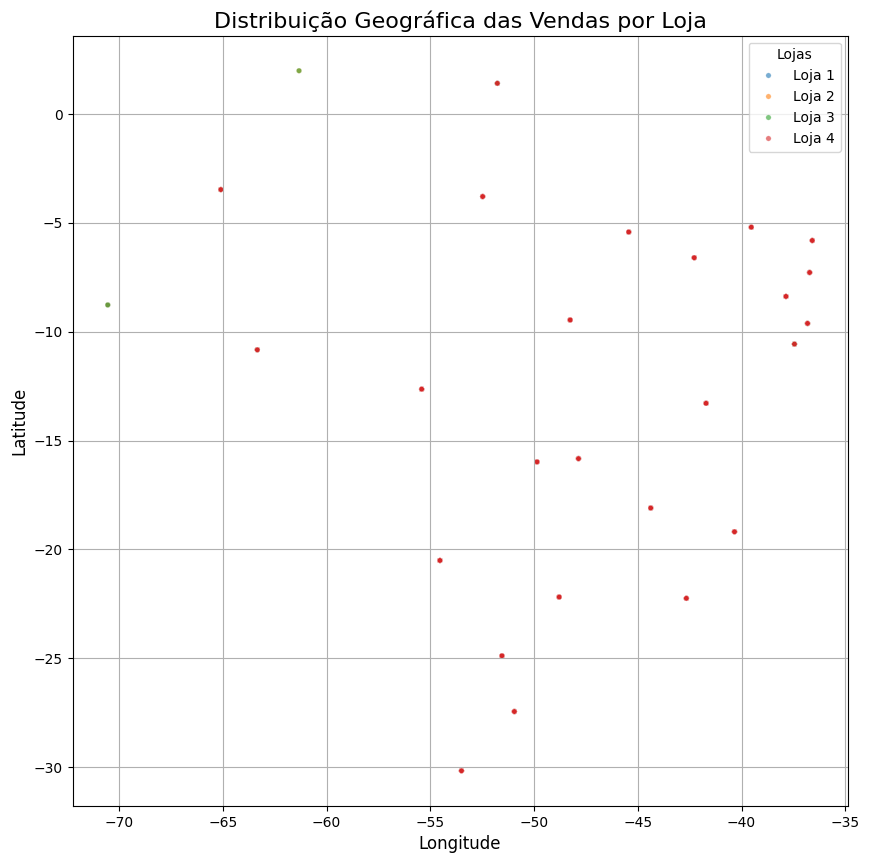

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,10))

sns.scatterplot(data=df_completo, x='lon', y='lat', hue='Loja', alpha =0.6, s=15)


plt.title('Distribuição Geográfica das Vendas por Loja', fontsize=16)
plt.xlabel('Longitude',fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(title='Lojas')

plt.grid(True)
plt.show

In [10]:
import folium
from folium.plugins import HeatMap


locations = df_completo[['lat','lon']].values.tolist()


mapa_calor =folium.Map(location=[-14.2350, -51.9253], zoom_start=4)


HeatMap(locations).add_to(mapa_calor)

mapa_calor
